# 06 Electrolyte (IA-ELY-001)

**Requirement:** `IA-ELY-001`

Patents: US12308414B2, EP4602674A1. Equations are paraphrased; see claims/paragraphs cited below.

## Governing equations

Default $6\,\mathrm{M}$ aqueous KOH. Carbonation

$$\mathrm{CO_2} + 2\,\mathrm{OH^-} \to \mathrm{CO_3^{2-}} + \mathrm{H_2O}$$

consumes $\mathrm{OH^-}$ and may clog pores (US). Alternate recipes from IA-SYS-021
(LiOH blends, NaOH, high hydroxide $\ge 7\,\mathrm{M}$ as a CE lever, EP).
Conductivity from `ironair.properties`.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

here = Path.cwd()
for cand in (here, here.parent):
    if (cand / "src" / "ironair").is_dir() and (cand / "plant_sim").is_dir():
        sys.path.insert(0, str(cand))
        sys.path.insert(0, str(cand / "src"))
        break

from plant_sim.bootstrap import setup_path

setup_path()
from plant_sim.params import CAPACITY_FE_OH2_MAH_G, CAPACITY_MAGNETITE_MAH_G, default_params

In [2]:
from IPython import get_ipython

_ipy = get_ipython()
if _ipy is not None:
    _ipy.run_line_magic("matplotlib", "inline")

sns.set(
    rc={
        "axes.labelsize": 12,
        "axes.titlesize": 18,
        "figure.figsize": (11, 8.5),
        "figure.dpi": 300,
        "figure.facecolor": "w",
        "figure.edgecolor": "k",
    }
)
P = default_params()
print("KOH default", P.c_KOH_mol_m3 / 1000, "M; T_ep", P.T_ep_sim_K, "K")
print("Faraday 960/320 checks", round(CAPACITY_FE_OH2_MAH_G, 2), round(CAPACITY_MAGNETITE_MAH_G, 2))

KOH default 6.0 M; T_ep 303.15 K
Faraday 960/320 checks 959.85 319.95


## Simulation setup

Integrate the model once. Plot sections below each document what is shown, why it matters for patent/requirement verification, and the equations that govern that view.


In [3]:
from plant_sim.components.electrolyte import Electrolyte
from plant_sim.components.base import integrate_component

ely = Electrolyte(P, filled=True)
t, y = integrate_component(
    lambda t, y: ely.rhs(
        t, y, {"r_iron_mol_s": 1e-6, "r_orr_mol_s": 5e-7, "x_CO2": 4.2e-4, "q_heat_W": 3.0, "T_amb_K": P.T_ep_sim_K}, {}
    ),
    ely.y0(),
    (0, 2000),
    n_eval=150,
)
cM = y[0] / np.maximum(y[5], 1e-12) / 1000

## Electrolyte fill, carbonation, temperature, wetting

### What this plot illustrates

Default $6\,\mathrm{M}$ KOH domain (IA-SYS-021), carbonate growth from $\mathrm{CO_2}$, temperature, and pore wetting saturation during fill.

### Governing equations

$$\mathrm{CO_2} + 2\,\mathrm{OH^-} \to \mathrm{CO_3^{2-}} + \mathrm{H_2O}$$

Inventory ODEs for $n_\mathrm{OH}$, $n_\mathrm{CO_3}$, $T$, $V$, and wetting $s$.


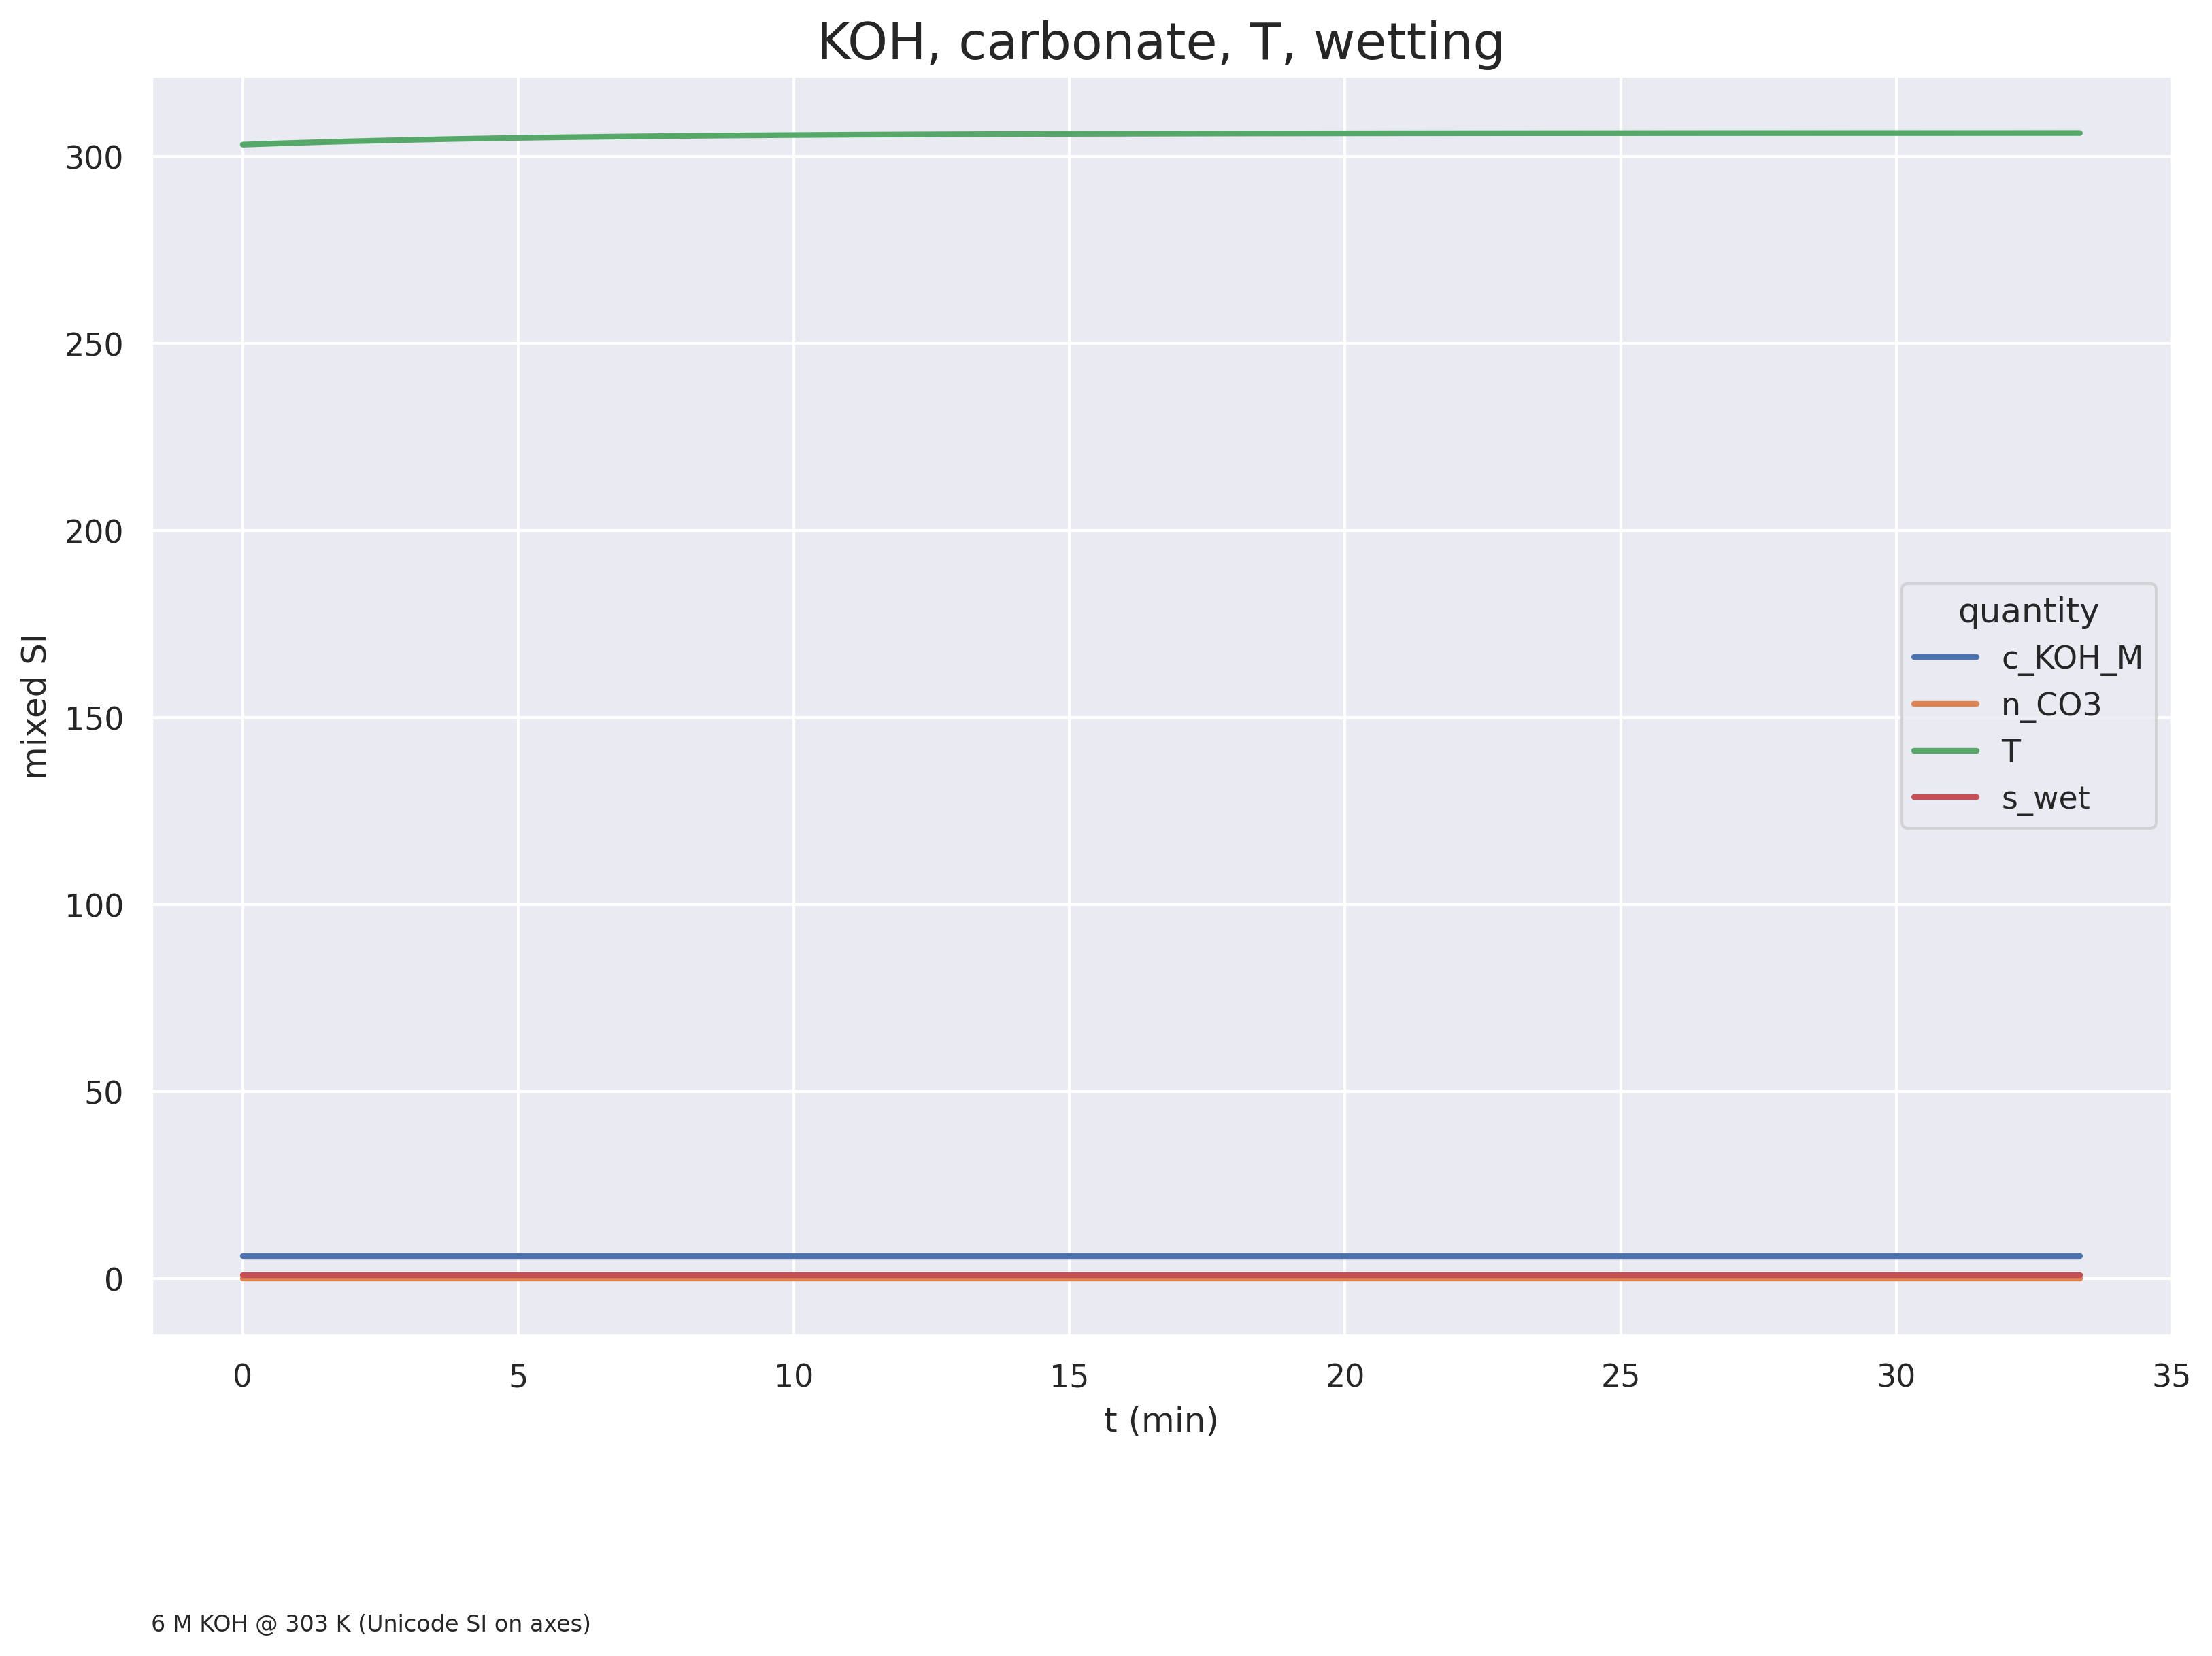

In [4]:
plot_frame = pd.DataFrame(
    {
        "t": (t / 60),
        "c_KOH_M": (cM),
        "n_CO3": (y[2]),
        "T": (y[4]),
        "s_wet": (y[6]),
    }
)
plot_long = plot_frame.melt(id_vars="t", var_name="quantity", value_name="value")
fig, ax = plt.subplots()
sns.lineplot(data=plot_long, x="t", y="value", hue="quantity", ax=ax, linewidth=2.0)
ax.set_xlabel("t (min)")
ax.set_ylabel("mixed SI")
ax.set_title("KOH, carbonate, T, wetting")
ax.text(0.0, -0.22, "6 M KOH @ 303 K (Unicode SI on axes)", transform=ax.transAxes, fontsize=8, va="top")
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)

## Numerical checks

Finite-trajectory and capacity checks for the integration above.


In [5]:
print("recipes", P.with_recipe("7M_KOH").c_KOH_mol_m3)

recipes 7000.0


## Verification against patents / SSS002

In [6]:
assert abs(P.c_KOH_mol_m3 / 1000 - 6) < 1e-9
print("PASS 6 M default")

PASS 6 M default
